# Classification Demo on the IRIS Dataset

This Notebook gives you a few example models and how they are trained on a simple classification dataset.

A classification task is a type of machine learning problem where the goal is to assign input data to one of several predefined categories or classes.

For this notebook we chose the Iris dataset. The goal is to predict the correct iris species ('setosa', 'versicolor', 'virginica') given width and height of pedals and sepals. The image below shows the three species.

The models that we used are:
1.   Decision Tree
2.   Random Forest
3. Support Vector Machine (/Classifier)
4. A fully connected Neural Network

Feel free to modify or add models (sklearn offers more models, like K-Nearest-neighbors or gradient boosting machines)





![image.png]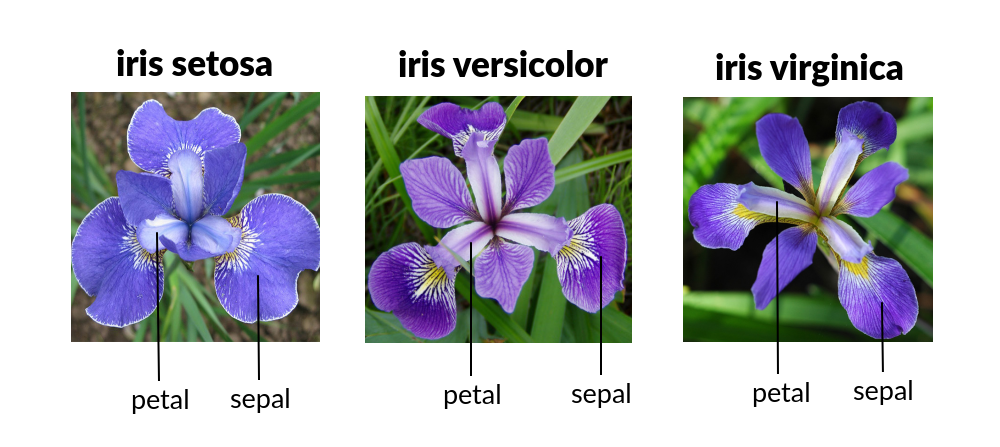

In [1]:
# All sklearn imports
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#numpy
import numpy as np

# pandas for dataframes
import pandas as pd

# matplotlib for plotting
import matplotlib.pyplot as plt

# tensorflow imports for the Neural Network at the end
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model

## Data Preprocessing

In the next Codeblocks we will


1.   Download the dataset
2.   Use a scaler to normalize the data
3. Split the data into training and testing sets



In [2]:
# Load the Iris dataset
iris = load_iris()

# The next few lines are only used to visualize the general structure of the dataset
# Create a DataFrame with the features
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In the table above we see the first 5 samples of the dataset.
Each sample has 4 different features:
1. sepal length
2. sepal width
3. petal length
4. petal width

and the target value:
5. species




The image below shows the three different Iris species in the dataset.

In [3]:
# Here we normalize the features so that the mean is roughly 0 and the standarddeviation 1
# This often improves the performance of machine learning algorithms

# load data (again) into a feature dataframe (X) and into a target dataframe (y)
X = pd.DataFrame(data=iris.data, columns=iris.feature_names)
y = pd.Categorical.from_codes(iris.target, iris.target_names)

# Initialize the scaler
scaler = StandardScaler() # Here you could also try the MinMaxScaler
# scaler = MinMaxScaler()

# Fit the scaler on X and transform
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (optional, for readability)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Here we can see a short overview of some key measurements of the dataset
# Should show mean ≈ 0 and std ≈ 1
X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,-1.468455e-15,1.00335,-1.870024,-0.900681,-0.052506,0.674501,2.492019
sepal width (cm),150.0,-1.823726e-15,1.00335,-2.433947,-0.592373,-0.131979,0.558611,3.090775
petal length (cm),150.0,-1.610564e-15,1.00335,-1.567576,-1.226552,0.336478,0.762758,1.785832
petal width (cm),150.0,-9.473903e-16,1.00335,-1.447076,-1.183812,0.132510,0.790671,1.712096


In [4]:
# Split dataset
# The train_test_split function is a great helper function to split your dataset into train and test set and also to shuffle the datasets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.25, shuffle=True, random_state=42)

In [17]:
# If you want to have a look on the data delete the # leading the next line
# X_train

In [18]:
# If you want to have a look on the data (target values) delete the # leading the next line
#y_train

In [7]:
# This function has nothing to do with data loading is is just a helper for easier model evaluation
# A simple function that evaluates the calssfier on the training and test set and prints the scores afterwards
def evaluate_and_print(clf):
  # Predict on the training data
  print("Score on Train")
  y_pred = clf.predict(X_train)
  accuracy = accuracy_score(y_train, y_pred)
  print("Accuracy: {:.2f}".format(accuracy))
  print("\nClassification Report:\n", classification_report(y_train, y_pred))

  print("-------------------------------------------------------------")

  # Predict on the test data
  print("Score on Test")
  y_pred = clf.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print("Accuracy: {:.2f}".format(accuracy))
  print("\nClassification Report:\n", classification_report(y_test, y_pred))

## Decision Tree

In [8]:
# Decision tree
# Create the classifier

# You can play around with someparameters:
# e.g try out another splitting criterion like "gini"
# Or a deeper tree, by setting max_depth to 5
clf = DecisionTreeClassifier(random_state=42, max_depth=3, criterion="entropy")


# Fit the model to the training data
clf.fit(X_train, y_train)


evaluate_and_print(clf)

Score on Train
Accuracy: 0.96

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        35
  versicolor       1.00      0.87      0.93        39
   virginica       0.88      1.00      0.94        38

    accuracy                           0.96       112
   macro avg       0.96      0.96      0.96       112
weighted avg       0.96      0.96      0.96       112

-------------------------------------------------------------
Score on Test
Accuracy: 0.97

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.91      0.95        11
   virginica       0.92      1.00      0.96        12

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



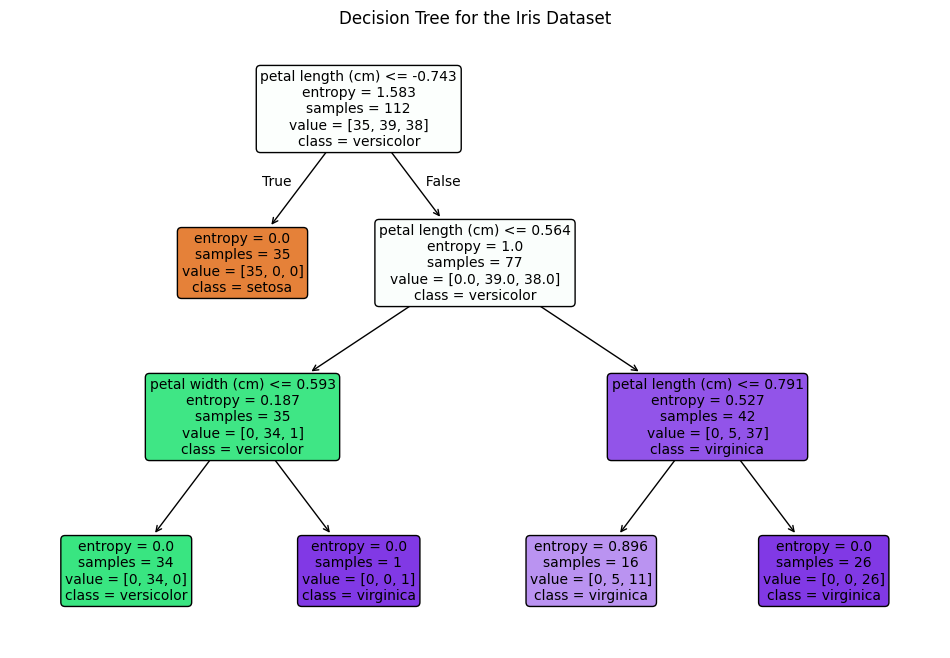

In [9]:
# Visualize the decision tree
plt.figure(figsize=(12, 8))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for the Iris Dataset")
plt.savefig("iris_tree.pdf", format="pdf")
plt.show()

## Random Forest Classifier
A random forest classifier builds several random trees and makes a decision based on the "votes" of the trees.

In [10]:
# Random Forest Classifier

# You can play around with someparameters:
# e.g try out another splitting criterion like "gini"
# Or shallower trees, by setting max_depth to 2
# More or less decision trees (n_estimators)
clf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5, criterion="entropy")


# Fit the model to the training data
clf.fit(X_train, y_train)


evaluate_and_print(clf)

Score on Train
Accuracy: 1.00

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        35
  versicolor       1.00      1.00      1.00        39
   virginica       1.00      1.00      1.00        38

    accuracy                           1.00       112
   macro avg       1.00      1.00      1.00       112
weighted avg       1.00      1.00      1.00       112

-------------------------------------------------------------
Score on Test
Accuracy: 1.00

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



## Support Vector Machine

In [11]:
# Support Vector Machine (Support Vector Classifier: SVC)
# Adapt the support vector classifier by using
# Differnt kernel functions: "linear", "rbf", "poly" or "sigmoid"
# Another Regularization (C), try out 0.01, 0.1 or 10
clf = SVC(kernel="sigmoid", C=1.0)


# Fit the model to the training data
clf.fit(X_train, y_train)


evaluate_and_print(clf)

Score on Train
Accuracy: 0.88

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      0.97      0.99        35
  versicolor       0.91      0.74      0.82        39
   virginica       0.78      0.95      0.86        38

    accuracy                           0.88       112
   macro avg       0.90      0.89      0.89       112
weighted avg       0.89      0.88      0.88       112

-------------------------------------------------------------
Score on Test
Accuracy: 0.87

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.64      0.74        11
   virginica       0.73      0.92      0.81        12

    accuracy                           0.87        38
   macro avg       0.87      0.85      0.85        38
weighted avg       0.88      0.87      0.87        38



## Fully Connected Feed Forward Neural Network

For Neural Networks we rely on Tensorflow.

In [12]:
# Since we can't train a TF model directly on the class names we convert them into "One-Hot" encodings
#
y_train = pd.get_dummies(y_train)
y_test = pd.get_dummies(y_test)

y_test.head() # Shows the one hot encoding

,setosa,versicolor,virginica
0,False,True,False
1,True,False,False
2,False,False,True
3,False,True,False
4,False,True,False


In [13]:
# First we build the model
# Input layer: input shape must be of shape [4], since we have 4 input features
# The first layer maps the 4 input neurons to 10 output neurons in a fully connected style
#
# The second layer is a fully connected layer mapping 10 neurons to 8
#
# The output layer is a fully connected layer mapping 8 neurons to 3 (the classes)
# The activation here is softmax, which ensures a correct distribution at the output neurons (sum is 1.0)
#
# You can adapt the number of output neurons and activation functions of the layers
# Or you can add or remove layers
model = Sequential([
    Dense(10, activation='relu', input_shape=[4]),
    Dense(8, activation='relu'), # try size 200 here
    # Dense(1, activation='relu'), # Try a bottleneck, all information must be stored in 1 neuron
    Dense(8, activation='relu'), # try size 200 here
    Dense(3, activation='softmax')  # 3 output neurons for 3 species
])

# Compile the model
# Before a Tensorflow model can be used it must be compiled
# Here we can set the optimizer that will be used (adam is a very advanced optimitzer), you can also try out SGD
# The loss function has to be categorical_crossentropy, since we optimize a calssification problem
# Metrics can be tracked during training, here accuracy is tracked
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


# Model summary() gives a short summary of the model
# This way you know how large each layer is and how many (trainable) weights there are
# Feel free to delete the # before model.summary() and have a look on the models paramaters
# model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Using plot_model you can visualize your model
# Here it is commented out, but feel free to use it

# plot_model(model, show_shapes=True, show_layer_names=True)

In [15]:
# Train the model
# Here the model is trained: After each batch (a set of 8 samples in this case) the optimizer updates the weights of the neural networks
# An epoch is one training cycle on the training dataset (depending on the batch size there are several batches and therefore weight updates per epoch)
# Feel free to choose another batch size or more epochs
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=8, verbose=1)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'\nTest accuracy: {accuracy:.2f}')

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.4552 - loss: 1.0549 - val_accuracy: 0.5789 - val_loss: 0.9950
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4901 - loss: 1.0275 - val_accuracy: 0.6842 - val_loss: 0.9540
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6553 - loss: 0.9674 - val_accuracy: 0.7105 - val_loss: 0.9086
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6637 - loss: 0.9114 - val_accuracy: 0.7105 - val_loss: 0.8583
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6273 - loss: 0.8866 - val_accuracy: 0.7105 - val_loss: 0.8078
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6764 - loss: 0.8065 - val_accuracy: 0.7105 - val_loss: 0.7548
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6980 - loss: 0.7762 - val_accuracy: 0.7105 - val_loss: 0.7001
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7140 - loss: 0.7283 - val_accuracy: 0.7105 - v

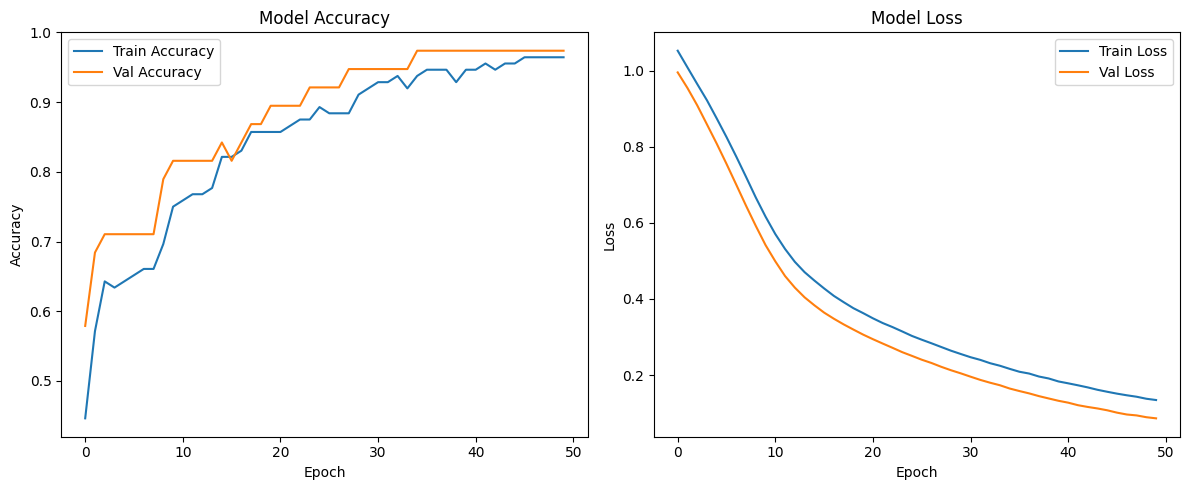

In [16]:
# In this code fragment we plot the model accuracy and model loss
# Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()